Usando UMAP para 10 classes de Glitches da O3b

Instalando as bibliotecas necessárias

In [4]:
!pip install --upgrade gwpy
!pip install --upgrade pandas
!pip install --upgrade uproot
!pip install --upgrade scikit-learn
!pip install --upgrade sns

  Using cached sns-0.1-py3-none-any.whl


Importando as Bibliotecas

In [3]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
warnings.filterwarnings("ignore", message="Pandas requires version")

from gwpy.segments import DataQualityFlag
from gwpy.table import EventTable
from gwpy.time import from_gps
from gwpy.time import to_gps
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D 
#from virgotools import getChannel
from sklearn.preprocessing import LabelEncoder
from glob import glob
import os
from datetime import datetime, timedelta
from astropy.table import unique as at_unique
from astropy.units import Unit, dimensionless_unscaled
from gwpy.timeseries import TimeSeries
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#import seaborn as sns
import umap
import glob as glob
%matplotlib inline

/home/lezinho/Desktop/code/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Os arquivos estão vetorizados já com as janelas temporais para cada glitch de [0.25, 0.5, 1.0, 2.0]
Nesses arquivos tem uma quantidade parecida de glitches para cada classe, que fica em torno de 500 para cada


In [16]:
arquivos_pkl = sorted(glob.glob('O3b/resultado1*.pkl'))
arquivos_pkl

['O3b/resultado1_dt_0.25.pkl',
 'O3b/resultado1_dt_0.5.pkl',
 'O3b/resultado1_dt_1.0.pkl',
 'O3b/resultado1_dt_2.0.pkl']

São basicamente duas colunas, uma contendo os vetores de posição dos glitches e o outro contendo a label de cada classe, dessa forma, devemos dividir essas duas colunas

In [32]:
v025 = pd.read_pickle('O3b/resultado1_dt_0.25.pkl')
vec025 = v025[0]
lab025 = v025[1]
lab025

        

['Power_Line',
 'Extremely_Loud',
 'Scattered_Light',
 'Air_Compressor',
 'Whistle',
 'Whistle',
 'Power_Line',
 'Low_Frequency_Lines',
 'Power_Line',
 'Blip',
 'Tomte',
 'Extremely_Loud',
 'Air_Compressor',
 'Extremely_Loud',
 'Air_Compressor',
 'Air_Compressor',
 'Tomte',
 'Blip',
 'Extremely_Loud',
 'Extremely_Loud',
 'Air_Compressor',
 'Air_Compressor',
 'Power_Line',
 'Tomte',
 'Air_Compressor',
 'Low_Frequency_Burst',
 'Whistle',
 'Blip',
 'Power_Line',
 'Power_Line',
 'Low_Frequency_Burst',
 'Air_Compressor',
 'Low_Frequency_Lines',
 'Blip',
 'Low_Frequency_Burst',
 'Extremely_Loud',
 'Low_Frequency_Lines',
 'Power_Line',
 'Blip',
 'Whistle',
 'Blip',
 'Air_Compressor',
 'Air_Compressor',
 'Low_Frequency_Burst',
 'Blip',
 'Air_Compressor',
 'Extremely_Loud',
 'Low_Frequency_Lines',
 'Low_Frequency_Lines',
 'Low_Frequency_Burst',
 'Extremely_Loud',
 'Scattered_Light',
 'Low_Frequency_Burst',
 'Scattered_Light',
 'Scattered_Light',
 'Scattered_Light',
 'Scattered_Light',
 'Scatter

Definindo os parâmetros para o UMAP:

In [ ]:
parametros_umap = {
    'n_neighbors': n,
    'min_dist': d,
    'n_components': 2,
    'metric': 'euclidean',
    'random_state': 42
}
reducer = umap.UMAP(**parametros_umap)
reducer.fit(vec025)

/home/lezinho/Desktop/code/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,n_jobs,1
,random_state,42
,tqdm_kwds,"{'bar_format': '{desc}: {percentage:3....{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True}"
,n_neighbors,15
,n_components,2
,metric,'euclidean'
,metric_kwds,None
,output_metric,'euclidean'
,output_metric_kwds,None
,n_epochs,None
,learning_rate,1.0


In [ ]:
embedding = reducer.fit_transform(vec025)


Gerando um esquema de cores diferentes para os labels diferentes

In [23]:
cmap = plt.colormaps["tab10"]
le = LabelEncoder()
labels = le.fit_transform(lab025)
labels

array([5, 2, 6, ..., 0, 0, 0], shape=(4487,))

In [35]:
vec025 = np.array(vec025)
lab025 = np.array(lab025)
vec025

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(4487, 1230))

Finalmente mostrando o gráfico da redução de dimensionalidade

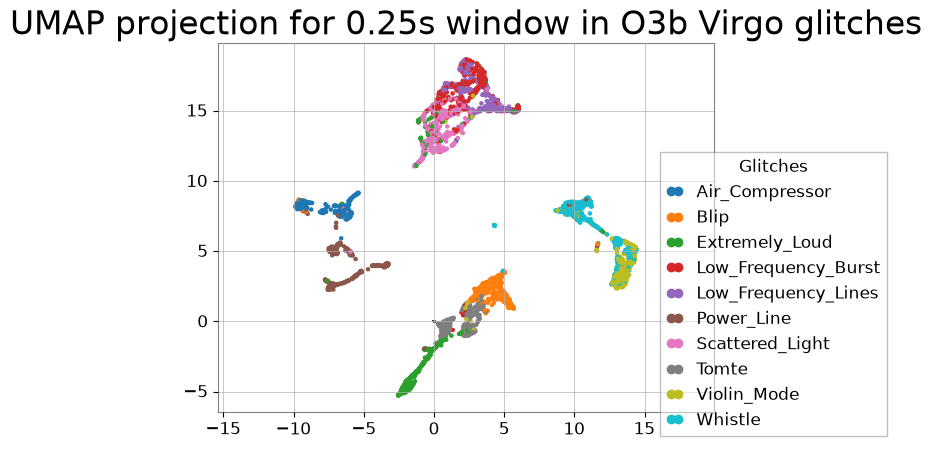

In [37]:
sc = plt.scatter(vec025[:,0], vec025[:,1], s=0.5, c=labels, cmap=cmap)
plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap=cmap, s=5)
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection for 0.25s window in O3b Virgo glitches', fontsize=24);
plt.legend(handles=sc.legend_elements()[0], labels=list(le.classes_), title="Glitches", loc='center', framealpha=0.5, markerscale=1.0, bbox_to_anchor=(1.12, 0.32))
plt.savefig('O3b/UMAP_projection_0.25s.png', dpi=300, bbox_inches='tight')

Usando todos os arquivos

In [6]:
v025 = pd.read_pickle('O3b/resultado1_dt_0.25.pkl')
v05 = pd.read_pickle('O3b/resultado1_dt_0.5.pkl')
v10 = pd.read_pickle('O3b/resultado1_dt_1.0.pkl')
v20 = pd.read_pickle('O3b/resultado1_dt_2.0.pkl')
vec025 = v025[0]
lab = v025[1]   

vec05 = v05[0]
lab05 = v05[1]

vec10 = v10[0]
lab10 = v10[1]

vec20 = v20[0]
lab20 = v20[1]

lab05

        

['Power_Line',
 'Extremely_Loud',
 'Scattered_Light',
 'Air_Compressor',
 'Whistle',
 'Whistle',
 'Power_Line',
 'Low_Frequency_Lines',
 'Power_Line',
 'Blip',
 'Tomte',
 'Extremely_Loud',
 'Air_Compressor',
 'Extremely_Loud',
 'Air_Compressor',
 'Air_Compressor',
 'Tomte',
 'Blip',
 'Extremely_Loud',
 'Extremely_Loud',
 'Air_Compressor',
 'Air_Compressor',
 'Power_Line',
 'Tomte',
 'Air_Compressor',
 'Low_Frequency_Burst',
 'Whistle',
 'Blip',
 'Power_Line',
 'Power_Line',
 'Low_Frequency_Burst',
 'Air_Compressor',
 'Low_Frequency_Lines',
 'Blip',
 'Low_Frequency_Burst',
 'Extremely_Loud',
 'Low_Frequency_Lines',
 'Air_Compressor',
 'Power_Line',
 'Blip',
 'Whistle',
 'Blip',
 'Air_Compressor',
 'Air_Compressor',
 'Low_Frequency_Burst',
 'Blip',
 'Air_Compressor',
 'Extremely_Loud',
 'Low_Frequency_Lines',
 'Low_Frequency_Lines',
 'Low_Frequency_Burst',
 'Extremely_Loud',
 'Scattered_Light',
 'Air_Compressor',
 'Low_Frequency_Burst',
 'Scattered_Light',
 'Scattered_Light',
 'Scattered

In [41]:
emb05 = reducer.fit(vec05)
emb10 = reducer.fit(vec10)
emb20 = reducer.fit(vec20)

In [42]:
embedding05 = reducer.fit_transform(vec05)
embedding10 = reducer.fit_transform(vec10)
embedding20 = reducer.fit_transform(vec20)

In [48]:
cmap = plt.colormaps["tab10"]
le = LabelEncoder()
la025 = le.fit_transform(lab025)
la05 = le.fit_transform(lab05)
la10 = le.fit_transform(lab10)
la20 = le.fit_transform(lab20)
la025

array([5, 2, 6, ..., 0, 0, 0], shape=(4487,))

Fazendo o gráfico para todos as quatro janelas

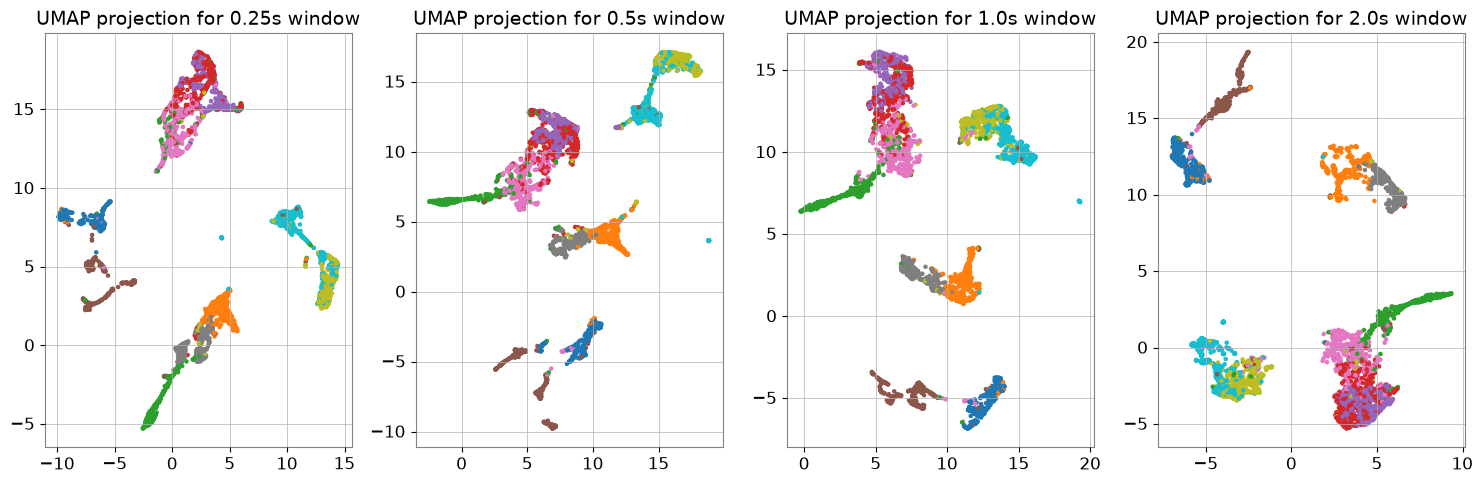

<Figure size 640x480 with 0 Axes>

In [52]:

fig, axs = plt.subplots(1, 4, figsize=(15, 5))
sc025 = axs[0].scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap=cmap, s=5)
axs[0].set_title('UMAP projection for 0.25s window', fontsize=14)

sc05 = axs[1].scatter(embedding05[:, 0], embedding05[:, 1], c=la05, cmap=cmap, s=5)
axs[1].set_title('UMAP projection for 0.5s window', fontsize=14)

sc10 = axs[2].scatter(embedding10[:, 0], embedding10[:, 1], c=la10, cmap=cmap, s=5)
axs[2].set_title('UMAP projection for 1.0s window', fontsize=14)

sc20 = axs[3].scatter(embedding20[:, 0], embedding20[:, 1], c=la20, cmap=cmap, s=5)
axs[3].set_title('UMAP projection for 2.0s window', fontsize=14)    

plt.tight_layout()

plt.show()
plt.savefig('O3b/UMAP_projection_all_windows.png', dpi=300, bbox_inches='tight')

Fazendo uma rotina para variar os parâmetros, que são para este caso, o número de vizinhos e a distância mínima

/home/lezinho/Desktop/code/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lezinho/Desktop/code/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lezinho/Desktop/code/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lezinho/Desktop/code/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lezinho/Desktop/code/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lezinho/Desktop/code/.venv/lib/python3.14/site-package

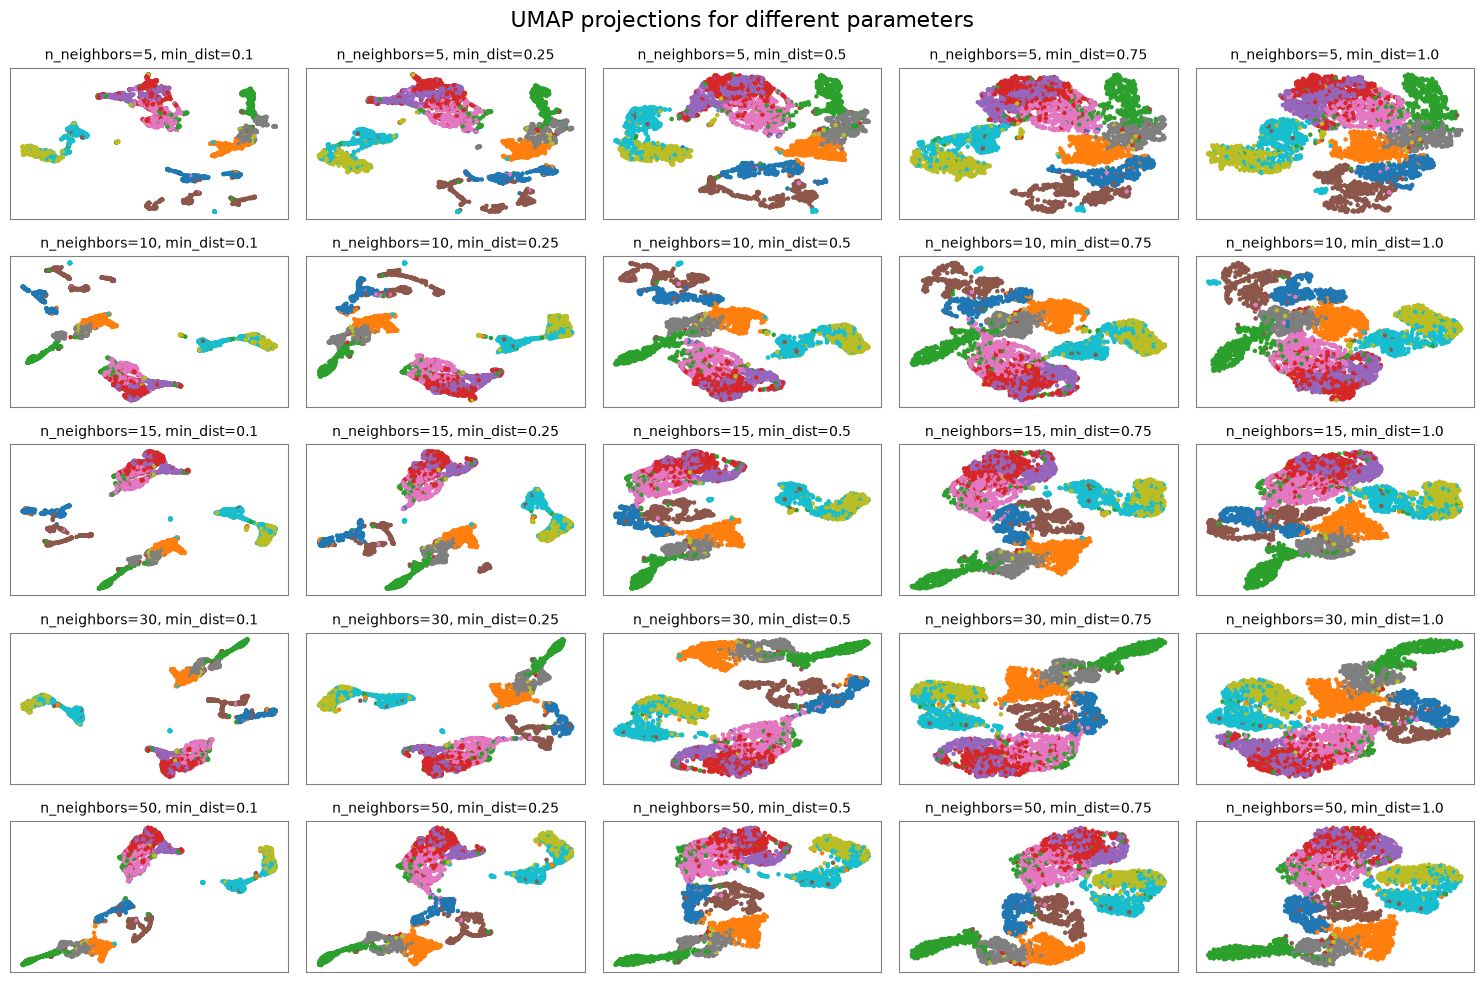

In [16]:
dist = [0.1, 0.25, 0.5, 0.75, 1.0]
neighbors = [5, 10, 15, 30, 50]
metrics = ['euclidean', 'manhattan', 'cosine', 'correlation']
reps = [0.01, 0.02, 0.05, 0.1, 0.2]
vecs = [vec025, vec05, vec10, vec20]

parametros_umap = {
    'n_neighbors': neighbors,
    'min_dist': dist,
    'n_components': 2,
    'metric': 'euclidean',
    'random_state': 42
}

cmap = plt.colormaps["tab10"]
le = LabelEncoder()
lab = le.fit_transform(lab)

fig, axes = plt.subplots(len(parametros_umap['n_neighbors']), len(parametros_umap['min_dist']), figsize=(15, 10))

for i, d in enumerate(dist):
    for j, n in enumerate(neighbors):
        reducer = umap.UMAP(n_neighbors=n, min_dist=d, n_components=2, metric='euclidean', random_state=42)
        embedding = reducer.fit_transform(vec025)

        ax = axes[j, i]
        sc = ax.scatter(embedding[:, 0], embedding[:, 1], c=lab, cmap=cmap, s=5)
        ax.set_title(f'n_neighbors={n}, min_dist={d}', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        

plt.suptitle('UMAP projections for different parameters', fontsize=16)
plt.tight_layout()
plt.savefig('O3b/UMAP_projection_different_parameters.png', dpi=300, bbox_inches='tight')
plt.show()

E aqui variando o número de vizinhos e a métrica. É possível observar que com a menor distância, temos uma clusterização melhor das classes e assim, sendo escolhido para as próximas análises a min_dist=0.1

/home/lezinho/Desktop/code/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lezinho/Desktop/code/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lezinho/Desktop/code/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lezinho/Desktop/code/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lezinho/Desktop/code/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lezinho/Desktop/code/.venv/lib/python3.14/site-package

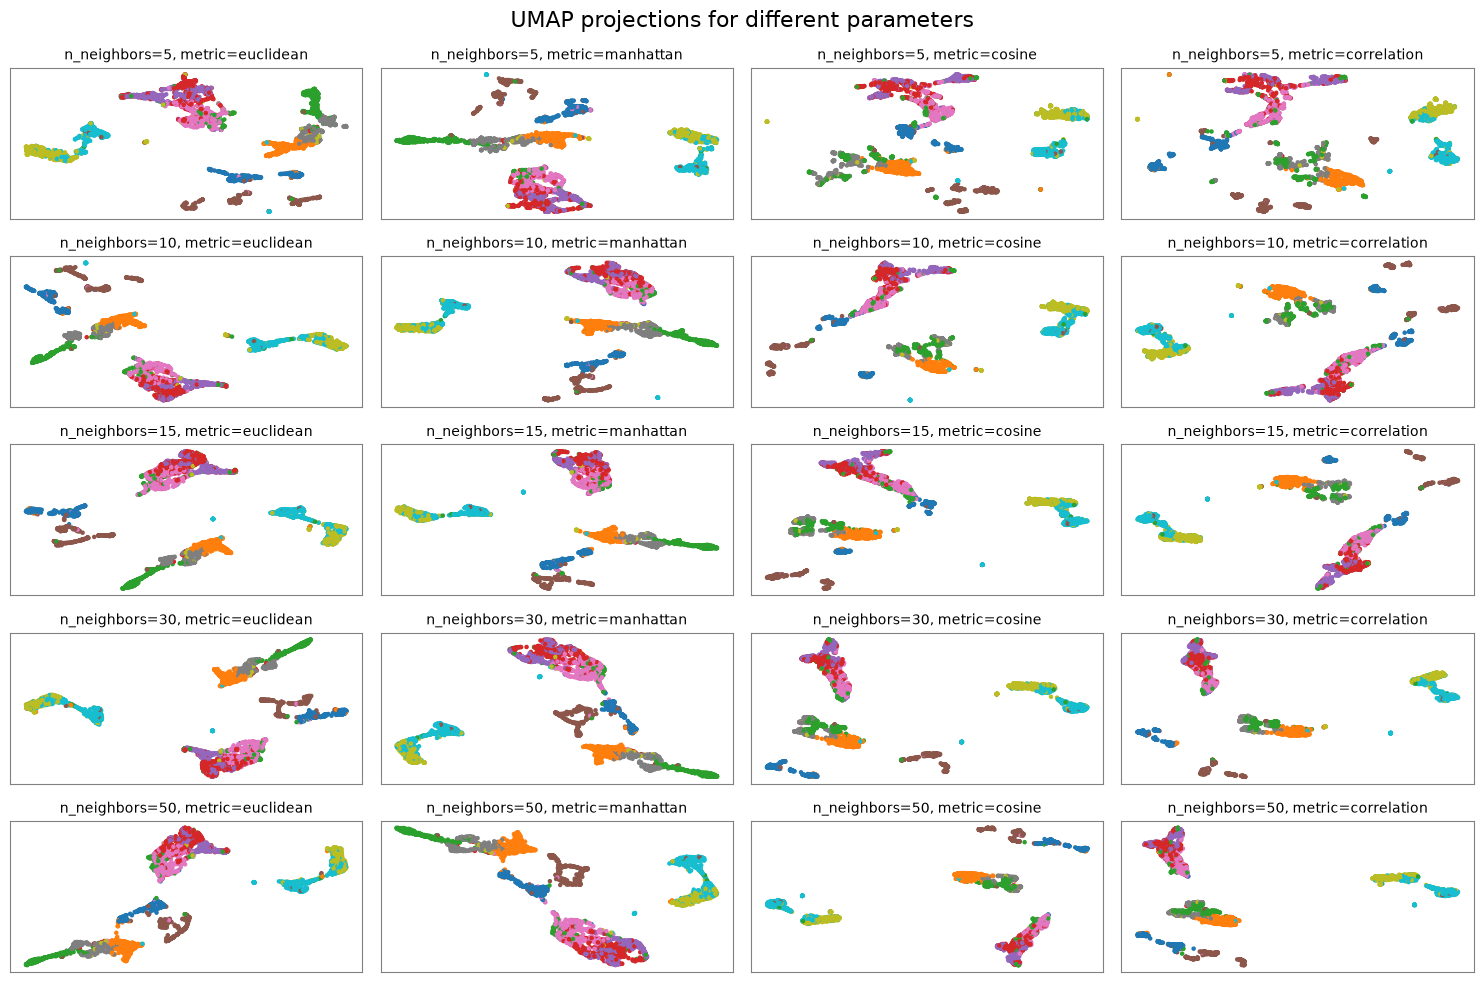

In [19]:
neighbors = [5, 10, 15, 30, 50]
metrics = ['euclidean', 'manhattan', 'cosine', 'correlation']
reps = [0.01, 0.02, 0.05, 0.1, 0.2]
vecs = [vec025, vec05, vec10, vec20]

parametros_umap = {
    'n_neighbors': neighbors,
    'min_dist': 0.1,
    'n_components': 2,
    'metric': metrics,
    'random_state': 42
}

cmap = plt.colormaps["tab10"]
le = LabelEncoder()
lab = le.fit_transform(lab)

fig, axes = plt.subplots(len(parametros_umap['n_neighbors']), len(parametros_umap['metric']), figsize=(15, 10))

for i, m in enumerate(metrics):
    for j, n in enumerate(neighbors):
        reducer = umap.UMAP(n_neighbors=n, min_dist=0.1, n_components=2, metric=m, random_state=42)
        embedding = reducer.fit_transform(vec025)

        ax = axes[j, i]
        sc = ax.scatter(embedding[:, 0], embedding[:, 1], c=lab, cmap=cmap, s=5)
        ax.set_title(f'n_neighbors={n}, metric={m}', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        

plt.suptitle('UMAP projections for different parameters', fontsize=16)
plt.tight_layout()
plt.savefig('O3b/UMAP_projection_different_parameters_metrics.png', dpi=300, bbox_inches='tight')
plt.show()